In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def coefficient_matrix(h, k):
    A = np.array([[1, h], 
                  [-h*k, 1]])
    return A
def stability_check(h, k):
    A   = coefficient_matrix(h, k)
    evs = np.linalg.eigvals(A)
    lam = np.abs(evs)
    if lam.max() < 1.0:
        return True
    else:
        return False


In [9]:
# Euler's Method Application
# Parameters
k = 1.0        # Spring constant
h = 0.01       # Step Size
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values

In [10]:
# Full Script with Stability Function
def stability_analysis(h, k, t_start, t_end, y_0, v_0):
    
    # Step Size
    print(f'Step Size h={h}')
    
    # Stability Check    
    stab = stability_check(h, k)
    if stab is True:
        print('Solution is Stable')
    else:
        print('Solution may not be Entirely Stable ;)')
        
    # Plotting
    plt.figure(figsize=(12, 6))
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
    plt.xlabel('Time (t)')
    plt.ylabel('Displacement (y)')
    plt.title('Euler\'s Method for a 2nd Order ODE')
    plt.legend()
    plt.grid(True)
    plt.show()
        
    return None

Step Size h=0.01
Solution may not be Entirely Stable ;)


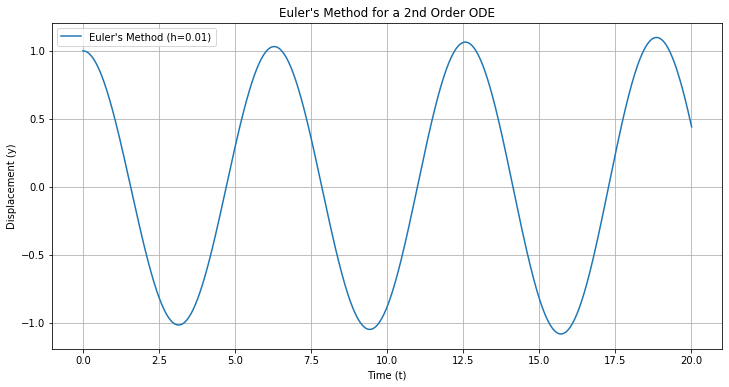

In [11]:
stability_analysis(h, k, t_start, t_end, y_0, v_0)